In [1]:
"""
Q-G-CTGAN: Quality-Aware Cluster-Conditioned Oversampling
via Intra-Cluster Synthetic Sample Filtering

Notebook 08: Quality Score Ablation (extended) & Adaptive Alpha
Visualization

Part A addresses Reviewer #1 (R1-7): the manuscript's composite
quality score Q(x̃) = (1/3)*S_density + (1/3)*S_sep + (1/3)*S_lof uses
equal weighting without sufficient justification. This notebook
extends the original manuscript's single-score-variant ablation
(Table 7, RF only, 11 datasets) to all 16 datasets, using the
target-aware bounded candidate multiplier introduced in Notebook 03
(rather than the original manuscript's fixed 5x multiplier) for
consistency with the main experiment's corrected pipeline.

Part B addresses Reviewer #4 (R4-5): Figure 4 in the manuscript
visualizes only the deterministic relationship defined by Eq. (8)
(alpha_c as a function of normalised log-likelihood) without empirical
validation. This notebook reconstructs Figure 4 using the actual
per-cluster alpha_c, log-likelihood, and REJECTION RATE (fraction of
Stage-1 candidates discarded) recorded during the main experiment
(Notebook 03), for representative datasets, matching the original
manuscript's presentation style (Section 4.4, "a couple of datasets"
rather than all 16).

Reads  : ./datasets/*.csv, ./results/03_qgctgan_results.csv (for cached
         quality_info if available, else recomputed here)
Writes : ./results/08_*.csv / *.png / *.pdf
"""

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings("ignore")

DATASET_DIR = "./datasets"
RESULTS_DIR = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 9,
    "font.family": "sans-serif", "pdf.fonttype": 42, "ps.fonttype": 42,
})

DATASET_NAMES = [
    "credit_default", "fraud_detection", "pima_diabetes", "ibm_attrition",
    "yeast_me2", "mammography", "abalone_19", "wine_quality",
    "ecoli", "pageblocks", "protein_homo",
    "satellite", "churn", "secom", "thyroid_sick", "unsw_nb15",
]

CANDIDATE_MULTIPLIER = 5.0
MAX_MULTIPLIER = 50.0
TARGET_RATIO = 0.50
ALPHA_MIN = 0.1
ALPHA_MAX = 0.3
MULTIPLIER_SAFETY_FACTOR = 1.5

print(f"Datasets: {len(DATASET_NAMES)}")

Datasets: 16


In [2]:
# ════════════════════════════════════════════════════════════
## Shared functions (identical to Notebook 03, reused for consistency)
# ════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import cdist
from sklearn.neighbors import LocalOutlierFactor
from ctgan import CTGAN


def get_rf_classifier(random_state=RANDOM_STATE):
    return RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=3,
        class_weight="balanced", random_state=random_state, n_jobs=-1,
    )


def fit_gmm(X_min, k, random_state=RANDOM_STATE):
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                           random_state=random_state, max_iter=200)
    gmm.fit(X_min)
    return gmm


def select_optimal_k(X_min, k_range=range(2, 11), random_state=RANDOM_STATE):
    bic_scores = {}
    for k in k_range:
        if len(X_min) < k * 2:
            break
        try:
            gmm = fit_gmm(X_min, k, random_state)
            bic_scores[k] = gmm.bic(X_min)
        except Exception:
            continue
    if not bic_scores:
        return 2, {}, fit_gmm(X_min, 2, random_state)
    best_k = min(bic_scores, key=bic_scores.get)
    return best_k, bic_scores, fit_gmm(X_min, best_k, random_state)


def s_density(X_syn, mu_c, sigma_c):
    try:
        sigma_inv = np.linalg.pinv(sigma_c)
        diff = X_syn - mu_c
        maha = np.sqrt(np.einsum("ij,jk,ik->i", diff, sigma_inv, diff))
        return np.exp(-maha)
    except Exception:
        return np.ones(len(X_syn)) * 0.5


def s_sep(X_syn, mu_minority_all, mu_majority_clusters, eps=1e-8):
    d_maj = cdist(X_syn, mu_majority_clusters).min(axis=1)
    d_min = cdist(X_syn, mu_minority_all).min(axis=1)
    return d_maj / (d_maj + d_min + eps)


def s_lof(X_syn, X_cluster_real, n_neighbors=5):
    X_combined = np.vstack([X_cluster_real, X_syn])
    n_nb = min(n_neighbors, len(X_cluster_real) - 1)
    if n_nb < 1:
        return np.ones(len(X_syn)) * 0.5
    try:
        lof = LocalOutlierFactor(n_neighbors=n_nb, novelty=False)
        lof.fit_predict(X_combined)
        lof_vals = -lof.negative_outlier_factor_[len(X_cluster_real):]
        return 1.0 / np.maximum(lof_vals, 1e-8)
    except Exception:
        return np.ones(len(X_syn)) * 0.5


def quality_score(X_syn, mu_c, sigma_c, mu_minority_all,
                  mu_majority_clusters, X_cluster_real, w=(1/3, 1/3, 1/3)):
    sd = s_density(X_syn, mu_c, sigma_c)
    ss = s_sep(X_syn, mu_minority_all, mu_majority_clusters)
    sl = s_lof(X_syn, X_cluster_real)
    def norm(v):
        lo, hi = v.min(), v.max()
        return (v - lo) / (hi - lo + 1e-8)
    return w[0]*norm(sd) + w[1]*norm(ss) + w[2]*norm(sl)


def compute_adaptive_alpha(gmm, X_min, labels, best_k,
                           alpha_min=ALPHA_MIN, alpha_max=ALPHA_MAX):
    log_liks = []
    for c in range(best_k):
        X_c = X_min[labels == c]
        ll = gmm.score_samples(X_c).mean() if len(X_c) >= 2 else -np.inf
        log_liks.append(ll)
    ll = np.array(log_liks, dtype=float)
    valid = ll[np.isfinite(ll)]
    if len(valid) == 0:
        return np.full(best_k, (alpha_min + alpha_max) / 2)
    ll = np.where(np.isfinite(ll), ll, valid.min())
    ll_min, ll_max = ll.min(), ll.max()
    ll_norm = (ll - ll_min) / (ll_max - ll_min + 1e-8)
    return np.clip(alpha_max - (alpha_max - alpha_min) * ll_norm, alpha_min, alpha_max)


def median_bandwidth(X, Y, sample_size=500):
    rng = np.random.default_rng(RANDOM_STATE)
    Xs = X[rng.choice(len(X), min(sample_size, len(X)), replace=False)]
    Ys = Y[rng.choice(len(Y), min(sample_size, len(Y)), replace=False)]
    Z = np.vstack([Xs, Ys])
    d = cdist(Z, Z, metric="sqeuclidean")
    return 1.0 / (2.0 * np.median(d[d > 0]) + 1e-8)


def rbf_kernel(X, Y, gamma=None):
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    XX = np.sum(X**2, axis=1, keepdims=True)
    YY = np.sum(Y**2, axis=1, keepdims=True)
    return np.exp(-gamma * (XX + YY.T - 2 * X @ Y.T))


def mmd_contribution(x_new, X_ref, X_pool, gamma):
    k_xref = rbf_kernel(x_new.reshape(1, -1), X_ref, gamma).mean()
    k_xsyn = rbf_kernel(x_new.reshape(1, -1), X_pool, gamma).mean() if len(X_pool) > 0 else 0.0
    return float(-2 * k_xref + k_xsyn)


def compute_required_multiplier(n_min, n_maj, target_ratio=TARGET_RATIO,
                                 base_multiplier=CANDIDATE_MULTIPLIER,
                                 safety_factor=MULTIPLIER_SAFETY_FACTOR,
                                 max_multiplier=MAX_MULTIPLIER):
    n_syn_needed = max(int(np.round(
        (target_ratio * (n_maj + n_min) - n_min) / (1 - target_ratio)
    )), 0)
    if n_min == 0:
        return base_multiplier, n_syn_needed
    required = (n_syn_needed * safety_factor) / n_min
    return float(np.clip(required, base_multiplier, max_multiplier)), n_syn_needed


def train_ctgan_per_cluster(X_min, labels, best_k, random_state=RANDOM_STATE):
    ctgan_models = {}
    for c in range(best_k):
        X_c = X_min[labels == c]
        if len(X_c) < 2:
            ctgan_models[c] = None
            continue
        cols = [f"f{i}" for i in range(X_c.shape[1])]
        X_c_df = pd.DataFrame(X_c, columns=cols)
        try:
            model = CTGAN(epochs=100, verbose=False)
            model.fit(X_c_df)
            ctgan_models[c] = model
        except Exception:
            ctgan_models[c] = None
    return ctgan_models


def generate_candidates(X_min, labels, best_k, ctgan_models, multiplier):
    candidates = {}
    for c in range(best_k):
        X_c = X_min[labels == c]
        n_gen = max(int(np.round(len(X_c) * multiplier)), 10)
        if ctgan_models.get(c) is None or len(X_c) < 2:
            candidates[c] = np.empty((0, X_min.shape[1]))
            continue
        try:
            candidates[c] = ctgan_models[c].sample(n_gen).values.astype(float)
        except Exception:
            candidates[c] = np.empty((0, X_min.shape[1]))
    return candidates

print("Shared functions loaded (identical to Notebook 03).")

Shared functions loaded (identical to Notebook 03).


In [4]:
def apply_qgctgan_ablation(X_train, y_train, weight_mode="full",
                            random_state=RANDOM_STATE, fixed_alpha=0.2):
    """
    weight_mode : "full"    -> w = (1/3, 1/3, 1/3)
                  "density" -> w = (1, 0, 0)
                  "sep"     -> w = (0, 1, 0)
                  "lof"     -> w = (0, 0, 1)
    Uses a FIXED alpha=0.2 (matching the manuscript's Table 7 protocol,
    which isolates the quality-score-weighting effect from the
    adaptive-threshold effect already ablated separately in Table 8 /
    Notebook 03).
    """
    w_map = {
        "full": (1/3, 1/3, 1/3), "density": (1, 0, 0),
        "sep": (0, 1, 0), "lof": (0, 0, 1),
    }
    w = w_map[weight_mode]
    X_min = X_train[y_train == 1].astype(float)
    X_maj = X_train[y_train == 0].astype(float)
    n_min, n_maj = len(X_min), len(X_maj)

    if n_maj - n_min <= 0:
        return X_train, y_train

    best_k, _, gmm = select_optimal_k(X_min, random_state=random_state)
    labels = gmm.predict(X_min)
    ctgan_models = train_ctgan_per_cluster(X_min, labels, best_k, random_state)

    multiplier, n_syn_needed = compute_required_multiplier(n_min, n_maj)
    candidates = generate_candidates(X_min, labels, best_k, ctgan_models, multiplier)

    alpha_vec = np.full(best_k, fixed_alpha)

    mu_minority_all = gmm.means_
    mu_majority_clusters = np.array([X_maj.mean(axis=0)])

    all_syn = []
    for c in range(best_k):
        X_cand = candidates[c]
        X_c = X_min[labels == c]
        if len(X_cand) == 0 or len(X_c) < 2:
            continue
        Q = quality_score(X_cand, gmm.means_[c], gmm.covariances_[c],
                          mu_minority_all, mu_majority_clusters, X_c, w=w)
        threshold = np.quantile(Q, alpha_vec[c])
        mask = Q >= threshold
        all_syn.append(X_cand[mask])

    if not all_syn:
        X_out = np.vstack([X_maj, X_min])
        return X_out, np.concatenate([np.zeros(n_maj), np.ones(n_min)]).astype(int)

    X_pool = np.vstack(all_syn)
    if len(X_pool) > n_syn_needed:
        gamma = median_bandwidth(X_min, X_pool)
        mmd_scores = np.array([
            mmd_contribution(X_pool[i], X_min, X_pool, gamma)
            for i in range(len(X_pool))
        ])
        X_pool = X_pool[np.argsort(mmd_scores)[:n_syn_needed]]

    X_out = np.vstack([X_maj, X_min, X_pool])
    y_out = np.concatenate([
        np.zeros(n_maj), np.ones(n_min), np.ones(len(X_pool))
    ]).astype(int)
    return X_out, y_out

print("Quality ablation function ready.")

Quality ablation function ready.


In [5]:
# ════════════════════════════════════════════════════════════
## Part A: Quality Score Component Ablation (R1-7)
# ════════════════════════════════════════════════════════════
# Extends the original manuscript's Table 7 (RF only, 11 datasets,
# fixed alpha=0.2) to all 16 datasets, using the target-aware bounded
# multiplier from Notebook 03 instead of the fixed 5x multiplier, for
# consistency with the corrected main pipeline.

def apply_qgctgan_ablation(X_train, y_train, weight_mode="full",
                            random_state=RANDOM_STATE, fixed_alpha=0.2):
    """
    weight_mode : "full"    -> w = (1/3, 1/3, 1/3)
                  "density" -> w = (1, 0, 0)
                  "sep"     -> w = (0, 1, 0)
                  "lof"     -> w = (0, 0, 1)
    Uses a FIXED alpha=0.2 (matching the manuscript's Table 7 protocol,
    which isolates the quality-score-weighting effect from the
    adaptive-threshold effect already ablated separately in Table 8 /
    Notebook 03).
    """
    w_map = {
        "full": (1/3, 1/3, 1/3), "density": (1, 0, 0),
        "sep": (0, 1, 0), "lof": (0, 0, 1),
    }
    w = w_map[weight_mode]
    X_min = X_train[y_train == 1].astype(float)
    X_maj = X_train[y_train == 0].astype(float)
    n_min, n_maj = len(X_min), len(X_maj)

    if n_maj - n_min <= 0:
        return X_train, y_train

    best_k, _, gmm = select_optimal_k(X_min, random_state=random_state)
    labels = gmm.predict(X_min)
    ctgan_models = train_ctgan_per_cluster(X_min, labels, best_k, random_state)

    multiplier, n_syn_needed = compute_required_multiplier(n_min, n_maj)
    candidates = generate_candidates(X_min, labels, best_k, ctgan_models, multiplier)

    alpha_vec = np.full(best_k, fixed_alpha)

    mu_minority_all = gmm.means_
    mu_majority_clusters = np.array([X_maj.mean(axis=0)])

    all_syn = []
    for c in range(best_k):
        X_cand = candidates[c]
        X_c = X_min[labels == c]
        if len(X_cand) == 0 or len(X_c) < 2:
            continue
        Q = quality_score(X_cand, gmm.means_[c], gmm.covariances_[c],
                          mu_minority_all, mu_majority_clusters, X_c, w=w)
        threshold = np.quantile(Q, alpha_vec[c])
        mask = Q >= threshold
        all_syn.append(X_cand[mask])

    if not all_syn:
        X_out = np.vstack([X_maj, X_min])
        return X_out, np.concatenate([np.zeros(n_maj), np.ones(n_min)]).astype(int)

    X_pool = np.vstack(all_syn)
    if len(X_pool) > n_syn_needed:
        gamma = median_bandwidth(X_min, X_pool)
        mmd_scores = np.array([
            mmd_contribution(X_pool[i], X_min, X_pool, gamma)
            for i in range(len(X_pool))
        ])
        X_pool = X_pool[np.argsort(mmd_scores)[:n_syn_needed]]

    X_out = np.vstack([X_maj, X_min, X_pool])
    y_out = np.concatenate([
        np.zeros(n_maj), np.ones(n_min), np.ones(len(X_pool))
    ]).astype(int)
    return X_out, y_out

print("Quality ablation function ready.")

Quality ablation function ready.


In [6]:
# ════════════════════════════════════════════════════════════
## Part A (continued): Main Execution Loop
# ════════════════════════════════════════════════════════════
# RF only, matching the manuscript's Table 7 protocol. Incremental
# save after each dataset.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ABLATION_MODES = ["full", "density", "sep", "lof"]
ablation_results = []
out_path = os.path.join(RESULTS_DIR, "08a_quality_ablation_results.csv")

print(f"Running quality indicator ablation (RF only, {len(DATASET_NAMES)} datasets)...")

for ds_name in DATASET_NAMES:
    path = os.path.join(DATASET_DIR, f"{ds_name}.csv")
    df = pd.read_csv(path)

    bool_cols = df.select_dtypes(include="bool").columns
    if len(bool_cols):
        df[bool_cols] = df[bool_cols].astype("float64")

    X = df.drop(columns=["target"]).values.astype(float)
    y = df["target"].values.astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    print(f"\n{'='*60}\nDataset: {ds_name}  n_train={len(X_train):,}\n{'='*60}")

    for wmode in ABLATION_MODES:
        t0 = time.time()
        try:
            X_res, y_res = apply_qgctgan_ablation(X_train.copy(), y_train.copy(), weight_mode=wmode)
            clf = get_rf_classifier()
            clf.fit(X_res, y_res)
            y_prob = clf.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_prob)
            elapsed = round(time.time() - t0, 2)
            ablation_results.append({
                "dataset": ds_name, "weight_mode": wmode, "AUC": round(auc, 4),
                "time_sec": elapsed,
            })
            print(f"  {wmode:<8} | AUC={auc:.4f}  [{elapsed:.1f}s]")
        except Exception as e:
            print(f"  {wmode:<8} | Error: {e}")

    pd.DataFrame(ablation_results).to_csv(out_path, index=False)

ablation_df = pd.DataFrame(ablation_results)
print(f"\nSaved {len(ablation_df)} rows to {out_path}")
print("\nAverage AUC per weight mode (across 16 datasets):")
print(ablation_df.groupby("weight_mode")["AUC"].mean().round(4).sort_values(ascending=False).to_string())

Running quality indicator ablation (RF only, 16 datasets)...

Dataset: credit_default  n_train=21,000
  full     | AUC=0.7656  [184.1s]
  density  | AUC=0.7631  [554.5s]
  sep      | AUC=0.7626  [537.5s]
  lof      | AUC=0.7641  [534.0s]

Dataset: fraud_detection  n_train=199,364
  full     | AUC=0.9650  [384.6s]
  density  | AUC=0.9584  [390.2s]
  sep      | AUC=0.9684  [381.1s]
  lof      | AUC=0.9684  [388.6s]

Dataset: pima_diabetes  n_train=537
  full     | AUC=0.8326  [95.5s]
  density  | AUC=0.8361  [94.1s]
  sep      | AUC=0.8359  [94.5s]
  lof      | AUC=0.8363  [97.6s]

Dataset: ibm_attrition  n_train=1,029
  full     | AUC=0.7720  [530.9s]
  density  | AUC=0.7683  [553.2s]
  sep      | AUC=0.7590  [541.0s]
  lof      | AUC=0.7774  [552.3s]

Dataset: yeast_me2  n_train=1,038
  full     | AUC=0.9270  [50.2s]
  density  | AUC=0.9159  [50.2s]
  sep      | AUC=0.9299  [50.1s]
  lof      | AUC=0.9179  [47.0s]

Dataset: mammography  n_train=7,828
  full     | AUC=0.9473  [193.1s]
 

In [7]:
# ════════════════════════════════════════════════════════════
## Part B: Adaptive Alpha Visualization (R4-5)
# ════════════════════════════════════════════════════════════
# Addresses Reviewer #4 (R4-5): Figure 4 in the manuscript visualizes
# only the deterministic relationship defined by Eq. (8) without
# empirical validation. This reconstructs Figure 4 using ACTUAL
# per-cluster log-likelihood, alpha_c, and REJECTION RATE (fraction of
# Stage-1 candidates discarded) from representative datasets spanning
# the IR range: Pima Diabetes (IR=1.87, low), Mammography (IR=42.01,
# medium), UNSW-NB15 (IR=99.42, high).

REPRESENTATIVE_DATASETS = ["pima_diabetes", "mammography", "unsw_nb15"]


def compute_cluster_diagnostics(X_train, y_train, random_state=RANDOM_STATE):
    """
    Runs GMM clustering + CTGAN training + candidate generation +
    Stage-1 filtering (adaptive alpha), and returns per-cluster
    diagnostics: log-likelihood, normalised log-likelihood, alpha_c,
    n_candidates, n_after_filter, rejection_rate.
    """
    X_min = X_train[y_train == 1].astype(float)
    X_maj = X_train[y_train == 0].astype(float)
    n_min, n_maj = len(X_min), len(X_maj)

    best_k, _, gmm = select_optimal_k(X_min, random_state=random_state)
    labels = gmm.predict(X_min)

    print(f"  GMM: best_k={best_k}, cluster_sizes={np.bincount(labels).tolist()}")

    ctgan_models = train_ctgan_per_cluster(X_min, labels, best_k, random_state)
    multiplier, n_syn_needed = compute_required_multiplier(n_min, n_maj)
    candidates = generate_candidates(X_min, labels, best_k, ctgan_models, multiplier)

    # Per-cluster mean log-likelihood (see Notebook 03's R4-2 note)
    log_liks = []
    for c in range(best_k):
        X_c = X_min[labels == c]
        ll = gmm.score_samples(X_c).mean() if len(X_c) >= 2 else -np.inf
        log_liks.append(ll)
    ll = np.array(log_liks, dtype=float)
    valid = ll[np.isfinite(ll)]
    ll = np.where(np.isfinite(ll), ll, valid.min() if len(valid) else 0)
    ll_min, ll_max = ll.min(), ll.max()
    ll_norm = (ll - ll_min) / (ll_max - ll_min + 1e-8)

    alpha_vec = compute_adaptive_alpha(gmm, X_min, labels, best_k)

    mu_minority_all = gmm.means_
    mu_majority_clusters = np.array([X_maj.mean(axis=0)])

    records = []
    for c in range(best_k):
        X_cand = candidates[c]
        X_c = X_min[labels == c]
        if len(X_cand) == 0 or len(X_c) < 2:
            records.append({
                "cluster": c, "log_likelihood": ll[c], "ll_norm": ll_norm[c],
                "alpha_c": alpha_vec[c], "n_candidate": 0, "n_after_filter": 0,
                "rejection_rate": np.nan,
            })
            continue

        Q = quality_score(X_cand, gmm.means_[c], gmm.covariances_[c],
                          mu_minority_all, mu_majority_clusters, X_c)
        threshold = np.quantile(Q, alpha_vec[c])
        mask = Q >= threshold
        n_after = int(mask.sum())
        rejection_rate = 1.0 - (n_after / len(X_cand))

        records.append({
            "cluster": c, "log_likelihood": ll[c], "ll_norm": ll_norm[c],
            "alpha_c": alpha_vec[c], "n_candidate": len(X_cand),
            "n_after_filter": n_after, "rejection_rate": round(rejection_rate, 4),
        })

    return pd.DataFrame(records)


alpha_diagnostics = {}
for ds_name in REPRESENTATIVE_DATASETS:
    path = os.path.join(DATASET_DIR, f"{ds_name}.csv")
    df = pd.read_csv(path)
    bool_cols = df.select_dtypes(include="bool").columns
    if len(bool_cols):
        df[bool_cols] = df[bool_cols].astype("float64")

    X = df.drop(columns=["target"]).values.astype(float)
    y = df["target"].values.astype(int)
    X_train, _, y_train, _ = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)

    print(f"\n{'='*60}\nDataset: {ds_name}\n{'='*60}")
    diag = compute_cluster_diagnostics(X_train, y_train)
    diag["dataset"] = ds_name
    alpha_diagnostics[ds_name] = diag
    print(diag.to_string(index=False))

all_diag = pd.concat(alpha_diagnostics.values(), ignore_index=True)
all_diag.to_csv(os.path.join(RESULTS_DIR, "08b_alpha_diagnostics.csv"), index=False)
print(f"\nSaved cluster diagnostics for {len(REPRESENTATIVE_DATASETS)} datasets.")


Dataset: pima_diabetes
  GMM: best_k=4, cluster_sizes=[62, 40, 59, 26]
 cluster  log_likelihood  ll_norm  alpha_c  n_candidate  n_after_filter  rejection_rate       dataset
       0        2.393454 1.000000 0.100000          310             279          0.1000 pima_diabetes
       1      -10.094009 0.000000 0.300000          200             140          0.3000 pima_diabetes
       2       -9.834511 0.020781 0.295844          295             208          0.2949 pima_diabetes
       3       -9.084538 0.080839 0.283832          130              93          0.2846 pima_diabetes

Dataset: mammography
  GMM: best_k=9, cluster_sizes=[18, 26, 11, 58, 4, 19, 30, 8, 8]
 cluster  log_likelihood  ll_norm  alpha_c  n_candidate  n_after_filter  rejection_rate     dataset
       0       -1.877592 0.228765 0.254247          900             671          0.2544 mammography
       1       -2.616753 0.189893 0.262021         1300             959          0.2623 mammography
       2       -4.190298 0.1071

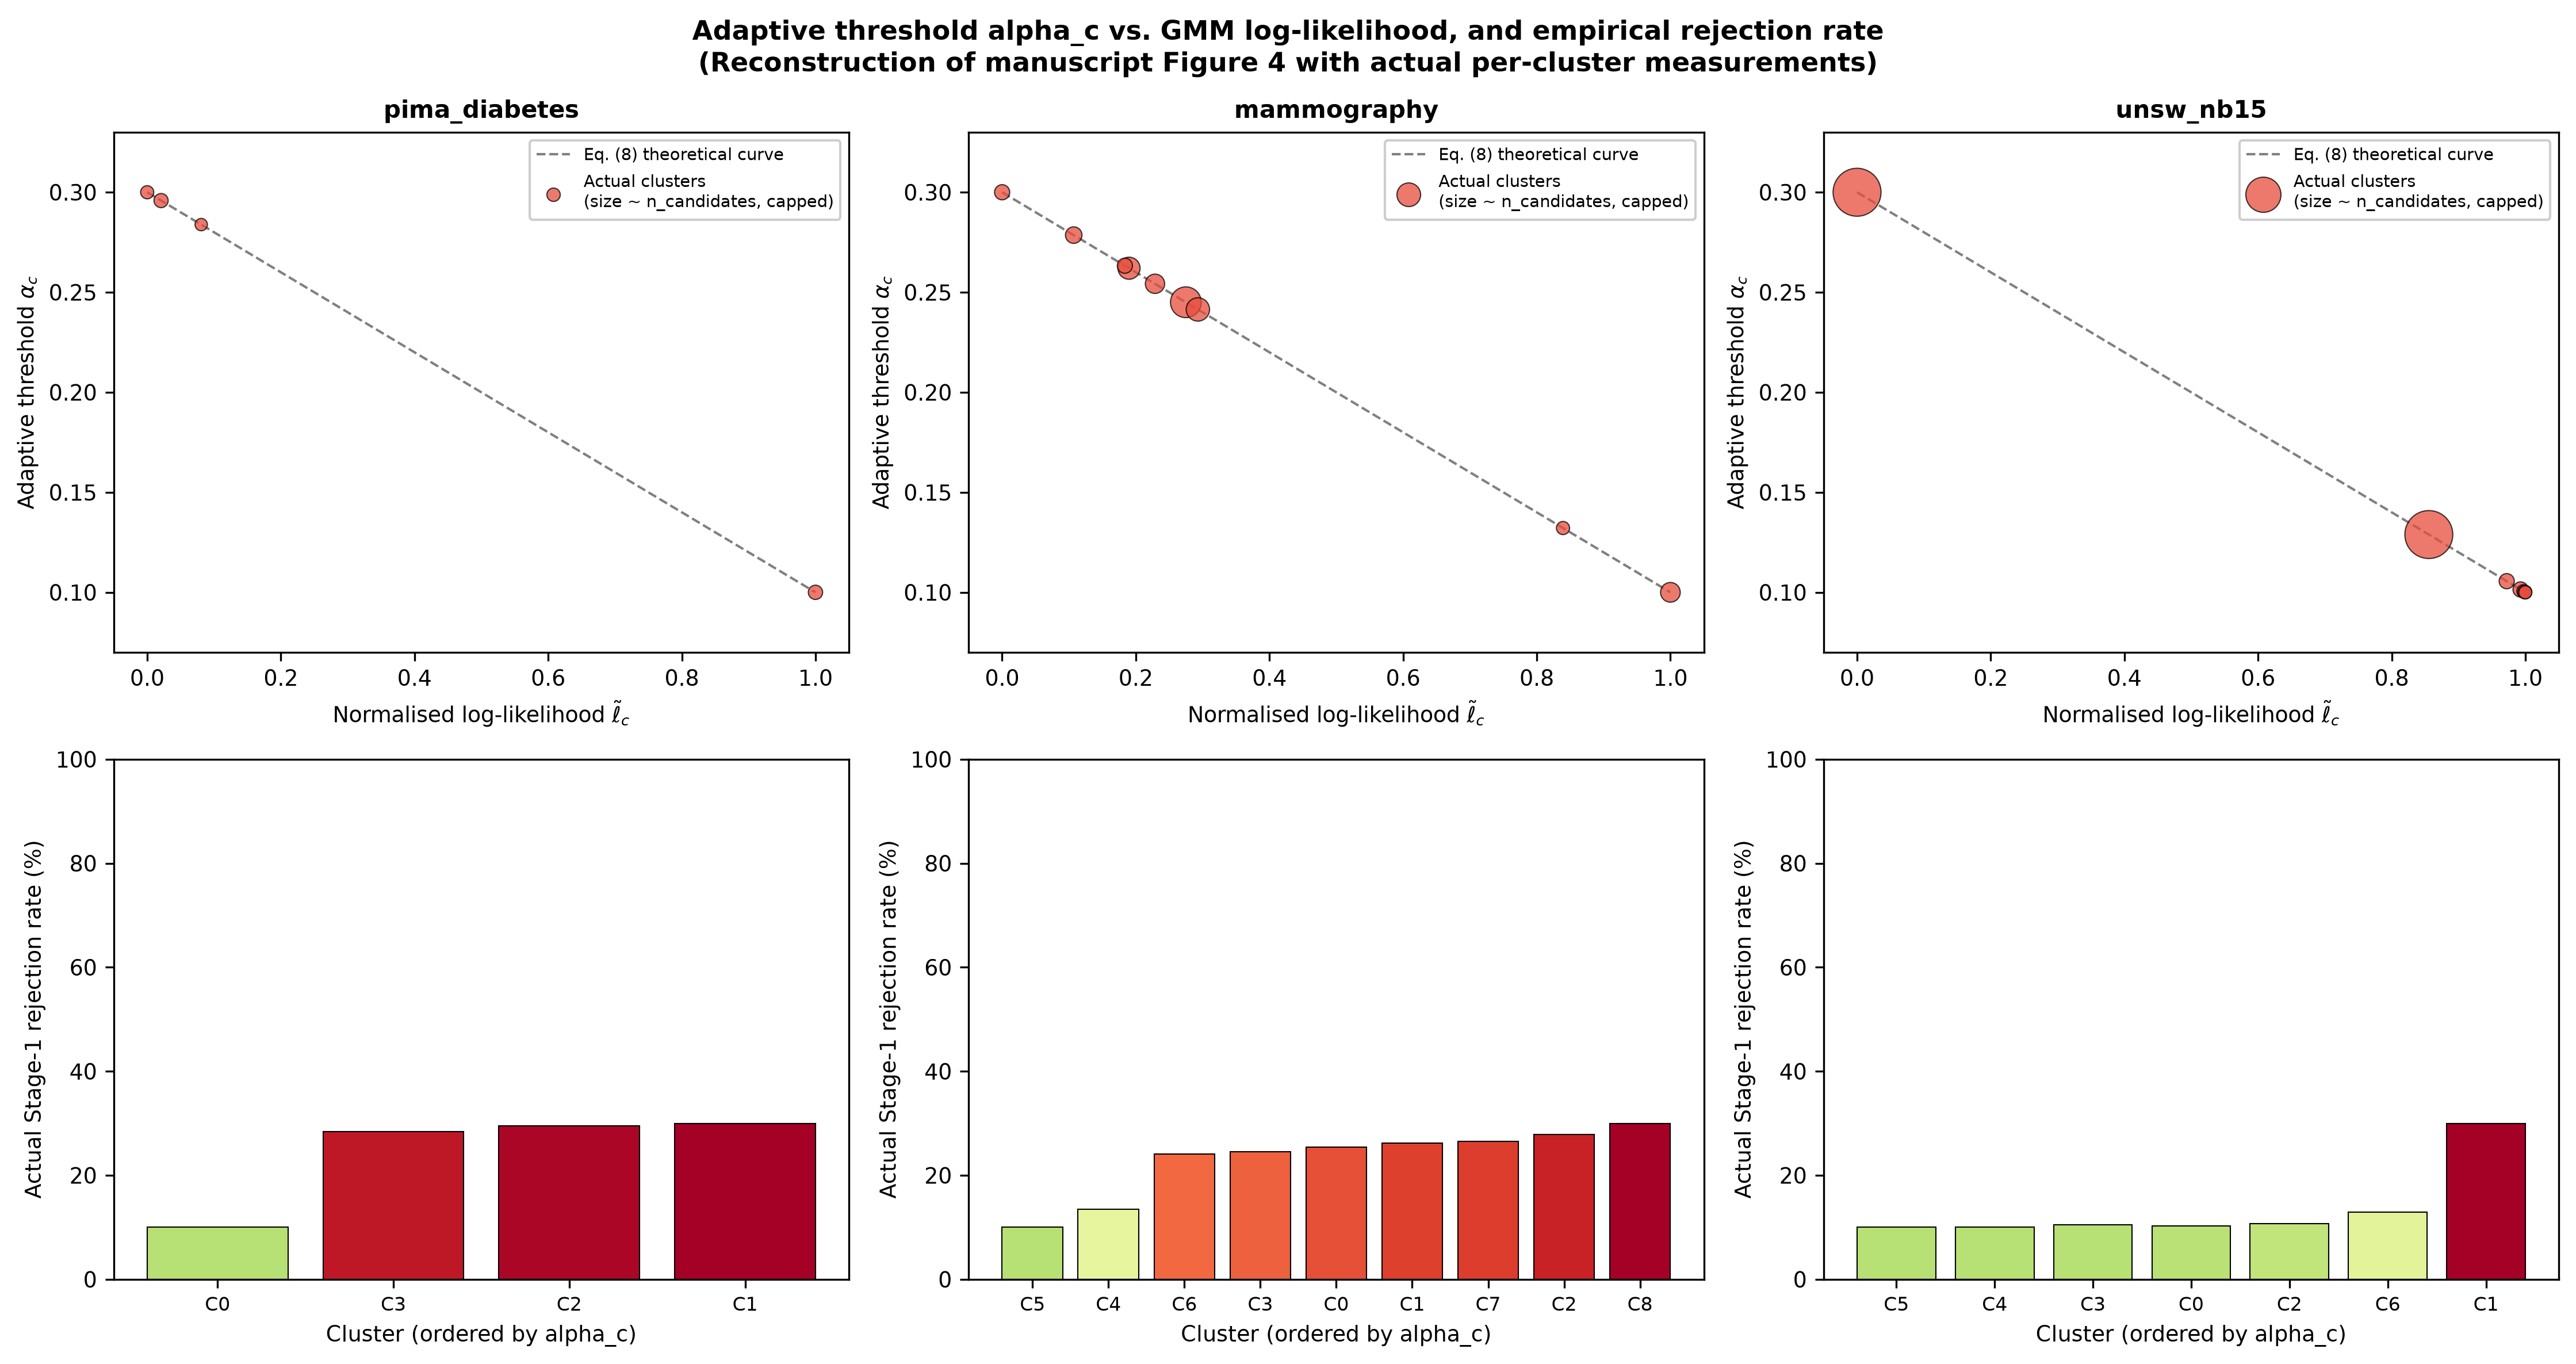

Saved: 08b_alpha_validation.png / .pdf (overwritten)


In [9]:
# Same code as before, with a small tweak: move the legend for unsw_nb15's
# top panel (which had the largest bubble overlapping the legend) to a
# less crowded location, and slightly reduce max bubble size to prevent
# overlap with panel titles.

fig, axes = plt.subplots(2, len(REPRESENTATIVE_DATASETS),
                          figsize=(5 * len(REPRESENTATIVE_DATASETS), 8))

for col_idx, ds_name in enumerate(REPRESENTATIVE_DATASETS):
    diag = alpha_diagnostics[ds_name]

    ax_top = axes[0, col_idx]
    ll_range = np.linspace(0, 1, 100)
    alpha_theoretical = ALPHA_MAX - (ALPHA_MAX - ALPHA_MIN) * ll_range
    ax_top.plot(ll_range, alpha_theoretical, "--", color="gray", linewidth=1,
                label="Eq. (8) theoretical curve", zorder=1)

    # Cap bubble size to avoid overlapping the title/legend on datasets
    # with very large clusters (e.g., unsw_nb15's 43,450-candidate cluster)
    bubble_size = np.clip(diag["n_candidate"] / 20 + 20, 20, 400)
    ax_top.scatter(diag["ll_norm"], diag["alpha_c"], s=bubble_size,
                    color="#E74C3C", alpha=0.75, edgecolor="black", linewidth=0.5,
                    zorder=2, label="Actual clusters\n(size ~ n_candidates, capped)")
    ax_top.set_xlabel(r"Normalised log-likelihood $\tilde{\ell}_c$", fontsize=9)
    ax_top.set_ylabel(r"Adaptive threshold $\alpha_c$", fontsize=9)
    ax_top.set_title(f"{ds_name}", fontsize=10, fontweight="bold")
    ax_top.legend(fontsize=7, loc="upper right", framealpha=0.95)
    ax_top.set_ylim(ALPHA_MIN - 0.03, ALPHA_MAX + 0.03)
    ax_top.set_xlim(-0.05, 1.05)

    ax_bot = axes[1, col_idx]
    diag_sorted = diag.sort_values("alpha_c")
    bar_colors = plt.cm.RdYlGn_r(diag_sorted["alpha_c"] / ALPHA_MAX)
    ax_bot.bar(range(len(diag_sorted)), diag_sorted["rejection_rate"] * 100,
               color=bar_colors, edgecolor="black", linewidth=0.5)
    ax_bot.set_xticks(range(len(diag_sorted)))
    ax_bot.set_xticklabels([f"C{c}" for c in diag_sorted["cluster"]], fontsize=8)
    ax_bot.set_xlabel("Cluster (ordered by alpha_c)", fontsize=9)
    ax_bot.set_ylabel("Actual Stage-1 rejection rate (%)", fontsize=9)
    ax_bot.set_ylim(0, 100)

plt.suptitle(
    "Adaptive threshold alpha_c vs. GMM log-likelihood, and empirical rejection rate\n"
    "(Reconstruction of manuscript Figure 4 with actual per-cluster measurements)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "08b_alpha_validation.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(RESULTS_DIR, "08b_alpha_validation.pdf"), bbox_inches="tight")
plt.show()
print("Saved: 08b_alpha_validation.png / .pdf (overwritten)")

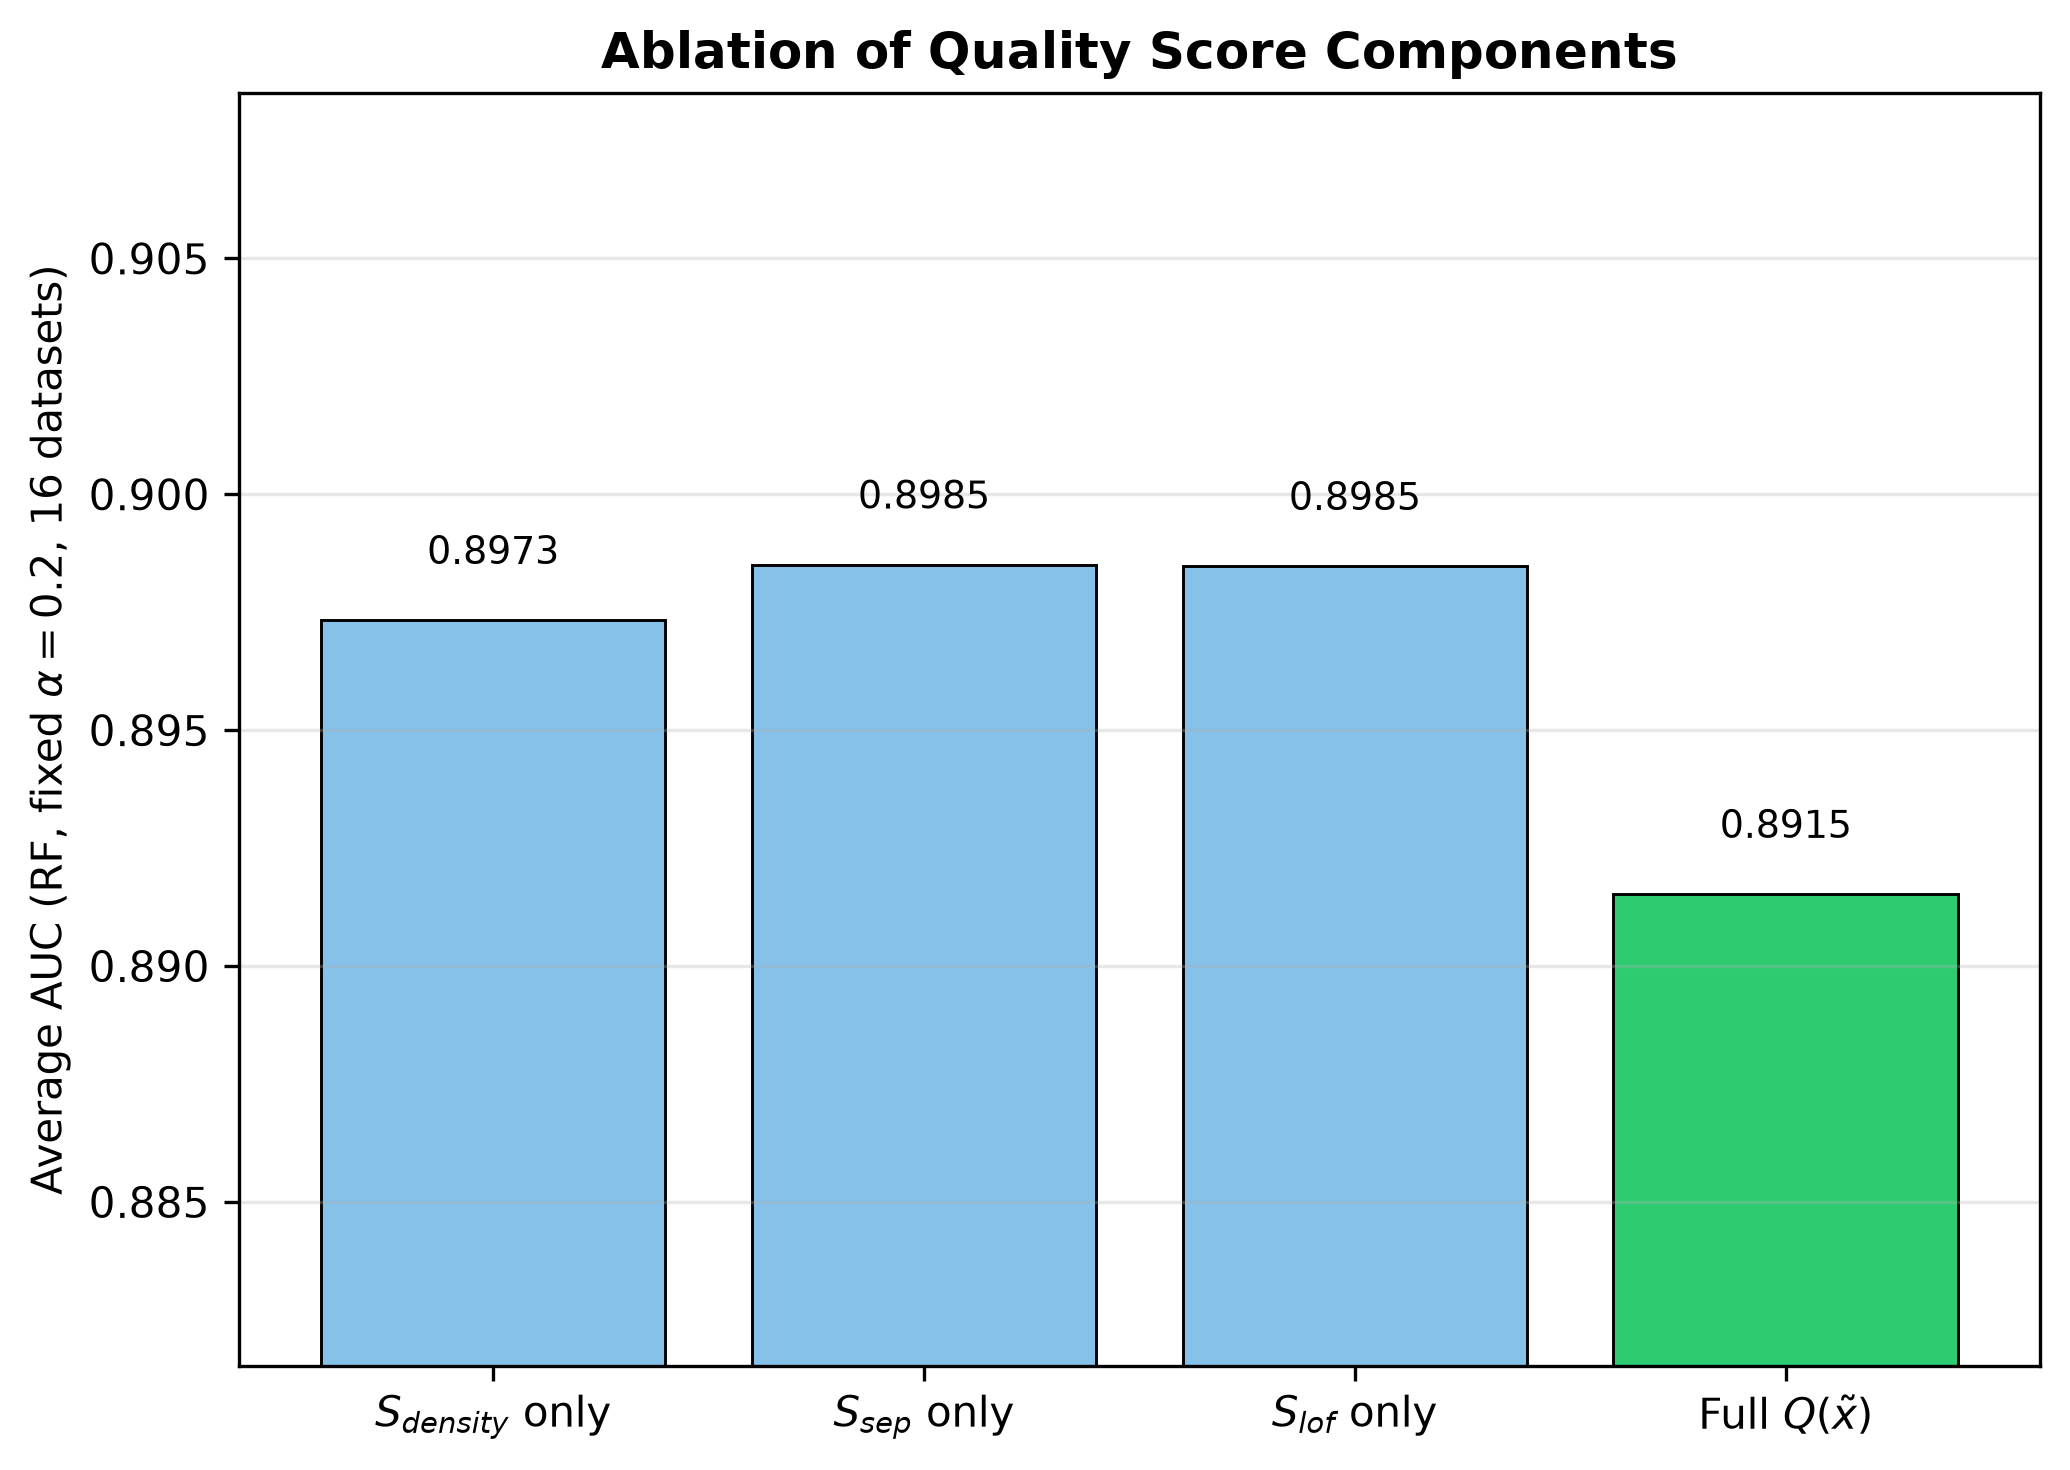

Saved: fig10_ablation_quality.png / .pdf

Average AUC by configuration:
weight_mode
density    0.8973
sep        0.8985
lof        0.8985
full       0.8915


In [10]:
"""
Visualization for Section 4.4.1 (Quality Score Components ablation):
bar chart of average AUC across all 16 datasets, RF, fixed alpha=0.2,
for the 4 quality-score configurations (S_density only, S_sep only,
S_lof only, full composite Q).

NOTE: the G-CTGAN reference line from an earlier version of this figure
is removed, since G-CTGAN is no longer a directly compared baseline in
this revision (relegated to Appendix G); the four configurations are
now compared against each other only.
"""

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 10,
    "font.family": "sans-serif", "pdf.fonttype": 42, "ps.fonttype": 42,
})

ablation_df = pd.read_csv("./results/08a_quality_ablation_results.csv", keep_default_na=False)

CONFIG_ORDER = ["density", "sep", "lof", "full"]
CONFIG_LABELS = {
    "density": r"$S_{density}$ only",
    "sep": r"$S_{sep}$ only",
    "lof": r"$S_{lof}$ only",
    "full": r"Full $Q(\tilde{x})$",
}

avg_by_config = ablation_df.groupby("weight_mode")["AUC"].mean().reindex(CONFIG_ORDER)
labels = [CONFIG_LABELS[c] for c in CONFIG_ORDER]

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#85C1E9", "#85C1E9", "#85C1E9", "#2ECC71"]  # highlight the proposed full composite
bars = ax.bar(labels, avg_by_config.values, color=colors, edgecolor="black", linewidth=0.7)

for bar, val in zip(bars, avg_by_config.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001, f"{val:.4f}",
            ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Average AUC (RF, fixed $\\alpha=0.2$, 16 datasets)", fontsize=10)
ax.set_title("Ablation of Quality Score Components", fontsize=12, fontweight="bold")
ax.set_ylim(min(avg_by_config.values) - 0.01, max(avg_by_config.values) + 0.01)
ax.grid(axis="y", alpha=0.3, zorder=0)

plt.tight_layout()
fig.savefig("./results/fig10_ablation_quality.png", dpi=300, bbox_inches="tight")
fig.savefig("./results/fig10_ablation_quality.pdf", bbox_inches="tight")
plt.show()
print("Saved: fig10_ablation_quality.png / .pdf")
print(f"\nAverage AUC by configuration:\n{avg_by_config.round(4).to_string()}")